In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/robikscube/hourly-energy-consumption/est_hourly.paruqet
/kaggle/input/datasets/robikscube/hourly-energy-consumption/DOM_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/EKPC_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/DUQ_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/DAYTON_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/PJME_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/PJM_Load_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/NI_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/FE_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/COMED_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/AEP_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/pjm_hourly_est.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/DEOK_hourly.csv
/kaggl

# Forecasting de Demanda Eléctrica Horaria

## Proyecto de Ciencia de Datos aplicado al consumo eléctrico

Este proyecto tiene como objetivo analizar y predecir la demanda eléctrica horaria utilizando datos históricos del sistema PJM Interconnection, una organización regional de transmisión eléctrica en Estados Unidos.

El dataset utilizado corresponde a **Hourly Energy Consumption**, disponible en Kaggle, el cual contiene registros horarios de consumo eléctrico medidos en megawatts para distintas zonas del mercado PJM.

El propósito del proyecto es construir un flujo completo de análisis de series de tiempo, desde la exploración inicial de los datos hasta la generación de modelos predictivos capaces de anticipar la demanda eléctrica futura.

## 1. Contexto del problema

La demanda eléctrica es una variable crítica para la planificación, operación y gestión de los sistemas energéticos. 

Una predicción adecuada del consumo permite anticipar períodos de alta demanda, mejorar la asignación de recursos, reducir riesgos operacionales y apoyar la toma de decisiones en generación, transmisión y distribución eléctrica.

En este proyecto se trabajará con datos horarios de consumo eléctrico, lo que permite capturar patrones de comportamiento asociados a:

- Horas del día.
- Días de la semana.
- Meses del año.
- Estacionalidad anual.
- Eventos de alta demanda o peak demand.

Este tipo de problema corresponde a un caso clásico de **forecasting de series de tiempo**, ampliamente utilizado en sectores como energía, retail, logística, finanzas y planificación operacional.

## 2. Objetivo del proyecto

El objetivo principal de este proyecto es desarrollar un modelo predictivo para estimar la demanda eléctrica horaria futura a partir de patrones históricos de consumo.

### Objetivos específicos

1. Cargar y explorar el dataset de consumo eléctrico horario.
2. Analizar la estructura temporal de la serie.
3. Identificar patrones horarios, diarios, semanales y mensuales.
4. Detectar períodos de alta demanda eléctrica.
5. Preparar variables temporales para modelamiento predictivo.
6. Entrenar modelos base de forecasting.
7. Comparar el desempeño de distintos enfoques predictivos.
8. Generar conclusiones orientadas a un contexto de negocio energético.

## 3. Carga de librerías

In [2]:
# ============================================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ============================================================

# Manipulación de datos
import os
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Series de tiempo y estadística
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Machine Learning
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Configuración general
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

plt.rcParams['figure.figsize'] = (14, 5)
sns.set_theme(style='whitegrid')

En esta etapa se importan las librerías necesarias para desarrollar el flujo completo del proyecto.

El proyecto utilizará `pandas` y `numpy` para manipulación de datos; `matplotlib`, `seaborn` y `plotly` para visualización; `statsmodels` para análisis estadístico de series de tiempo; y `scikit-learn` para modelamiento predictivo y evaluación de resultados.

La incorporación de distintas librerías permite enriquecer el análisis sin perder coherencia metodológica. Python será el lenguaje principal del proyecto, mientras que R se incorporará posteriormente como anexo metodológico complementario.

## 4. Revisión de archivos disponibles en Kaggle

Antes de cargar un archivo específico, se inspecciona el directorio de entrada de Kaggle para identificar todos los archivos disponibles dentro del dataset.

Esto es importante porque el dataset contiene múltiples archivos CSV asociados a distintas zonas eléctricas del sistema PJM.

In [3]:
# ============================================================
# 2. EXPLORACIÓN DE ARCHIVOS DISPONIBLES
# ============================================================

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/robikscube/hourly-energy-consumption/est_hourly.paruqet
/kaggle/input/datasets/robikscube/hourly-energy-consumption/DOM_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/EKPC_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/DUQ_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/DAYTON_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/PJME_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/PJM_Load_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/NI_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/FE_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/COMED_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/AEP_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/pjm_hourly_est.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/DEOK_hourly.csv
/kaggl

El dataset contiene distintos archivos asociados a zonas o subconjuntos del sistema eléctrico PJM. 

Para desarrollar una primera versión controlada del proyecto, se seleccionará inicialmente el archivo `PJME_hourly.csv`, correspondiente a una zona específica del mercado PJM.

Trabajar primero con una sola serie permite construir una metodología clara de análisis y modelamiento, la cual posteriormente puede ser extendida a otras zonas eléctricas.

## 5. Carga del dataset principal

Para esta primera etapa del proyecto se utilizará el archivo `PJME_hourly.csv`.

Este archivo contiene registros horarios de consumo eléctrico en megawatts. Cada observación representa el nivel de demanda eléctrica registrado en una fecha y hora específica.

In [4]:
# ============================================================
# 3. CARGA DEL DATASET PRINCIPAL
# ============================================================

path = '/kaggle/input/datasets/robikscube/hourly-energy-consumption/PJME_hourly.csv'

df = pd.read_csv(path)

df.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,"26,498.00"
1,2002-12-31 02:00:00,"25,147.00"
2,2002-12-31 03:00:00,"24,574.00"
3,2002-12-31 04:00:00,"24,393.00"
4,2002-12-31 05:00:00,"24,860.00"


La vista inicial del dataset permite confirmar que la información está estructurada en dos columnas principales:

- `Datetime`: fecha y hora del registro.
- `PJME_MW`: consumo eléctrico medido en megawatts.

Esta estructura es adecuada para construir una serie de tiempo univariada, donde la variable objetivo será el consumo eléctrico horario.

## 6. Exploración inicial del dataset

En esta sección se revisan las dimensiones del dataset, los tipos de datos, las columnas disponibles y la presencia de valores nulos.

Este paso es fundamental para detectar problemas iniciales de calidad de datos antes de avanzar hacia el análisis temporal y el modelamiento predictivo.

In [5]:
# ============================================================
# 4. EXPLORACIÓN INICIAL DEL DATASET
# ============================================================

print("Dimensiones del dataset:")
print(df.shape)

print("\nColumnas disponibles:")
print(df.columns)

print("\nTipos de datos:")
print(df.dtypes)

print("\nValores nulos por columna:")
print(df.isnull().sum())

print("\nPrimeras filas:")
display(df.head())

print("\nÚltimas filas:")
display(df.tail())

Dimensiones del dataset:
(145366, 2)

Columnas disponibles:
Index(['Datetime', 'PJME_MW'], dtype='object')

Tipos de datos:
Datetime     object
PJME_MW     float64
dtype: object

Valores nulos por columna:
Datetime    0
PJME_MW     0
dtype: int64

Primeras filas:


,Datetime,PJME_MW
0,2002-12-31 01:00:00,"26,498.00"
1,2002-12-31 02:00:00,"25,147.00"
2,2002-12-31 03:00:00,"24,574.00"
3,2002-12-31 04:00:00,"24,393.00"
4,2002-12-31 05:00:00,"24,860.00"



Últimas filas:


,Datetime,PJME_MW
145361,2018-01-01 20:00:00,"44,284.00"
145362,2018-01-01 21:00:00,"43,751.00"
145363,2018-01-01 22:00:00,"42,402.00"
145364,2018-01-01 23:00:00,"40,164.00"
145365,2018-01-02 00:00:00,"38,608.00"


La exploración inicial permite verificar la cantidad de registros disponibles, el tipo de dato de cada columna y la existencia de valores nulos.

Dado que se trata de una serie temporal horaria, es especialmente importante revisar que la columna de fecha sea convertida correctamente a formato `datetime` y que los registros queden ordenados cronológicamente.

## 7. Preparación de la serie temporal

Para trabajar correctamente con series de tiempo, la columna `Datetime` debe convertirse a formato temporal y utilizarse como índice del dataframe.

Esto permitirá realizar operaciones temporales como agregaciones por hora, día, semana, mes y año, además de facilitar la construcción de variables predictivas basadas en el calendario.

In [6]:
# ============================================================
# 5. PREPARACIÓN DE LA COLUMNA DATETIME
# ============================================================

df['Datetime'] = pd.to_datetime(df['Datetime'])

df = df.sort_values('Datetime')

df = df.set_index('Datetime')

df.head()

,PJME_MW
Datetime,
2002-01-01 01:00:00,"30,393.00"
2002-01-01 02:00:00,"29,265.00"
2002-01-01 03:00:00,"28,357.00"
2002-01-01 04:00:00,"27,899.00"
2002-01-01 05:00:00,"28,057.00"


In [7]:
# ============================================================
# 6. REVISIÓN DEL RANGO TEMPORAL
# ============================================================

print("Fecha inicial:", df.index.min())
print("Fecha final:", df.index.max())
print("Cantidad total de registros:", len(df))

Fecha inicial: 2002-01-01 01:00:00
Fecha final: 2018-08-03 00:00:00
Cantidad total de registros: 145366


Una vez convertida la columna `Datetime`, el dataset queda estructurado como una serie temporal indexada por fecha y hora.

Esto facilita el análisis cronológico de la demanda eléctrica y permite identificar el rango histórico cubierto por los datos.

## 8. Visualización general del consumo eléctrico

La primera visualización de la serie completa permite observar el comportamiento general de la demanda eléctrica a lo largo del tiempo.

Este gráfico ayuda a identificar visualmente patrones de estacionalidad, cambios de nivel, períodos de alta variabilidad y posibles eventos extremos de consumo.

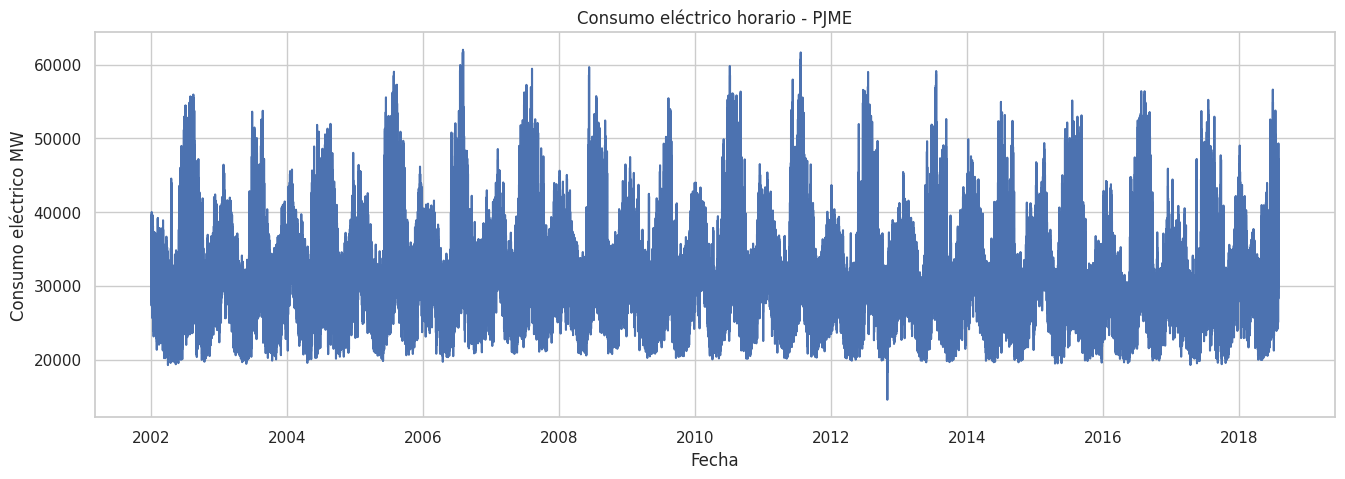

In [8]:
# ============================================================
# 7. VISUALIZACIÓN GENERAL DE LA SERIE TEMPORAL
# ============================================================

plt.figure(figsize=(16, 5))
plt.plot(df.index, df['PJME_MW'])
plt.title('Consumo eléctrico horario - PJME')
plt.xlabel('Fecha')
plt.ylabel('Consumo eléctrico MW')
plt.grid(True)
plt.show()

La serie muestra una alta frecuencia de observaciones debido a que los datos son horarios.

A simple vista se pueden observar fluctuaciones recurrentes en la demanda eléctrica, lo que sugiere la presencia de patrones temporales asociados al comportamiento diario, semanal y estacional del consumo.

## 9. Creación de variables temporales

Para analizar y modelar una serie de tiempo horaria, es necesario extraer información del calendario a partir del índice temporal.

Estas variables permiten capturar patrones recurrentes del consumo eléctrico asociados a distintos niveles de agregación temporal, como la hora del día, el día de la semana, el mes y el año.

En esta etapa se crearán variables temporales que posteriormente serán utilizadas tanto para el análisis exploratorio como para el modelamiento predictivo.

In [9]:
# ============================================================
# 8. CREACIÓN DE VARIABLES TEMPORALES
# ============================================================

df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['dayofmonth'] = df.index.day
df['dayofyear'] = df.index.dayofyear
df['weekofyear'] = df.index.isocalendar().week.astype(int)
df['month'] = df.index.month
df['quarter'] = df.index.quarter
df['year'] = df.index.year

df.head()

,PJME_MW,hour,dayofweek,dayofmonth,dayofyear,weekofyear,month,quarter,year
Datetime,,,,,,,,,
2002-01-01 01:00:00,"30,393.00",1,1,1,1,1,1,1,2002
2002-01-01 02:00:00,"29,265.00",2,1,1,1,1,1,1,2002
2002-01-01 03:00:00,"28,357.00",3,1,1,1,1,1,1,2002
2002-01-01 04:00:00,"27,899.00",4,1,1,1,1,1,1,2002
2002-01-01 05:00:00,"28,057.00",5,1,1,1,1,1,1,2002


Las variables temporales creadas permiten descomponer el comportamiento de la demanda eléctrica en distintas dimensiones de tiempo.

Esto es especialmente relevante porque el consumo eléctrico no suele comportarse de manera aleatoria, sino que responde a rutinas humanas, ciclos laborales, condiciones climáticas y patrones estacionales.

## 10. Validación y tratamiento de continuidad temporal

Dado que el dataset corresponde a datos horarios, se espera que entre un registro y otro exista una diferencia de una hora.

La validación inicial detectó timestamps duplicados y algunas fechas faltantes dentro del rango histórico. En problemas de forecasting, estos aspectos deben tratarse antes de entrenar modelos predictivos, ya que muchos algoritmos asumen observaciones igualmente espaciadas en el tiempo.

Para corregir la serie, se consolidan los duplicados utilizando el promedio y posteriormente se reconstruye el índice horario completo, imputando los valores faltantes mediante interpolación temporal.

In [10]:
# ============================================================
# 9. VALIDACIÓN DE DUPLICADOS TEMPORALES
# ============================================================

duplicated_dates = df.index.duplicated().sum()

print("Cantidad de fechas duplicadas:", duplicated_dates)

if duplicated_dates > 0:
    print("\nFechas duplicadas detectadas:")
    display(df[df.index.duplicated(keep=False)].sort_index())

Cantidad de fechas duplicadas: 4

Fechas duplicadas detectadas:


,PJME_MW,hour,dayofweek,dayofmonth,dayofyear,weekofyear,month,quarter,year
Datetime,,,,,,,,,
2014-11-02 02:00:00,"23,755.00",2,6,2,306,44,11,4,2014
2014-11-02 02:00:00,"22,935.00",2,6,2,306,44,11,4,2014
2015-11-01 02:00:00,"21,567.00",2,6,1,305,44,11,4,2015
2015-11-01 02:00:00,"21,171.00",2,6,1,305,44,11,4,2015
2016-11-06 02:00:00,"20,795.00",2,6,6,311,44,11,4,2016
2016-11-06 02:00:00,"21,692.00",2,6,6,311,44,11,4,2016
2017-11-05 02:00:00,"21,236.00",2,6,5,309,44,11,4,2017
2017-11-05 02:00:00,"20,666.00",2,6,5,309,44,11,4,2017


La validación detecta la existencia de registros duplicados para algunas fechas y horas.

En una serie temporal horaria, cada timestamp debería representar una única observación. Por lo tanto, los duplicados deben ser tratados antes de realizar análisis agregados o entrenar modelos predictivos.

In [11]:
# ============================================================
# 10. TRATAMIENTO DE DUPLICADOS TEMPORALES
# ============================================================

# Si existen timestamps duplicados, se consolida la información usando el promedio.
# Esta decisión es conservadora porque mantiene la señal temporal sin eliminar completamente información.

df = df.groupby(df.index).mean()

print("Cantidad de fechas duplicadas después del tratamiento:", df.index.duplicated().sum())
print("Dimensiones después de tratar duplicados:", df.shape)

Cantidad de fechas duplicadas después del tratamiento: 0
Dimensiones después de tratar duplicados: (145362, 9)


In [12]:
# ============================================================
# 11. VALIDACIÓN DE FRECUENCIA HORARIA
# ============================================================

expected_range = pd.date_range(
    start=df.index.min(),
    end=df.index.max(),
    freq='h'
)

missing_dates = expected_range.difference(df.index)

print("Cantidad de fechas esperadas:", len(expected_range))
print("Cantidad de registros reales:", len(df))
print("Cantidad de fechas faltantes:", len(missing_dates))

if len(missing_dates) > 0:
    print("\nPrimeras fechas faltantes:")
    print(missing_dates[:10])

Cantidad de fechas esperadas: 145392
Cantidad de registros reales: 145362
Cantidad de fechas faltantes: 30

Primeras fechas faltantes:
DatetimeIndex(['2002-04-07 03:00:00', '2002-10-27 02:00:00',
               '2003-04-06 03:00:00', '2003-10-26 02:00:00',
               '2004-04-04 03:00:00', '2004-10-31 02:00:00',
               '2005-04-03 03:00:00', '2005-10-30 02:00:00',
               '2006-04-02 03:00:00', '2006-10-29 02:00:00'],
              dtype='datetime64[ns]', freq=None)


La revisión de frecuencia horaria permite identificar si existen horas faltantes dentro del rango temporal completo.

En este caso, al tratarse de un número bajo de fechas faltantes en relación con el tamaño total del dataset, se optará por reconstruir el índice horario completo e imputar los valores faltantes mediante interpolación temporal.

In [13]:
# ============================================================
# 12. TRATAMIENTO DE FECHAS FALTANTES
# ============================================================

# Se reconstruye la serie con frecuencia horaria completa.
df = df.reindex(expected_range)

# Se asigna nombre al índice para mantener claridad en el dataframe.
df.index.name = 'Datetime'

# Se imputan valores faltantes de la variable objetivo mediante interpolación temporal.
df['PJME_MW'] = df['PJME_MW'].interpolate(method='time')

# Validación posterior al tratamiento.
missing_after = df['PJME_MW'].isnull().sum()

print("Valores faltantes en PJME_MW después de interpolar:", missing_after)
print("Cantidad final de registros:", len(df))
print("Fecha inicial:", df.index.min())
print("Fecha final:", df.index.max())

Valores faltantes en PJME_MW después de interpolar: 0
Cantidad final de registros: 145392
Fecha inicial: 2002-01-01 01:00:00
Fecha final: 2018-08-03 00:00:00


In [14]:
# ============================================================
# 13. RECREACIÓN DE VARIABLES TEMPORALES DESPUÉS DEL REINDEX
# ============================================================

df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['dayofmonth'] = df.index.day
df['dayofyear'] = df.index.dayofyear
df['weekofyear'] = df.index.isocalendar().week.astype(int)
df['month'] = df.index.month
df['quarter'] = df.index.quarter
df['year'] = df.index.year

df.head()

,PJME_MW,hour,dayofweek,dayofmonth,dayofyear,weekofyear,month,quarter,year
Datetime,,,,,,,,,
2002-01-01 01:00:00,"30,393.00",1,1,1,1,1,1,1,2002
2002-01-01 02:00:00,"29,265.00",2,1,1,1,1,1,1,2002
2002-01-01 03:00:00,"28,357.00",3,1,1,1,1,1,1,2002
2002-01-01 04:00:00,"27,899.00",4,1,1,1,1,1,1,2002
2002-01-01 05:00:00,"28,057.00",5,1,1,1,1,1,1,2002


Después del tratamiento, la serie queda con una frecuencia horaria continua, sin duplicados y con valores faltantes imputados de forma controlada.

Dado que la cantidad de fechas faltantes es baja respecto del total de registros, la interpolación temporal es una solución razonable para esta etapa del proyecto.

Esta decisión permite conservar la estructura temporal necesaria para modelos de forecasting y evita que los modelos reciban una serie irregular.

## 11. Estadística descriptiva del consumo eléctrico

Antes de analizar patrones temporales específicos, se revisan las principales estadísticas descriptivas de la variable objetivo `PJME_MW`.

Este análisis permite conocer el nivel promedio de demanda, la variabilidad del consumo y los valores mínimos y máximos registrados durante el período histórico.

In [15]:
# ============================================================
# 14. ESTADÍSTICA DESCRIPTIVA DE LA VARIABLE OBJETIVO
# ============================================================

df['PJME_MW'].describe()

count   145,392.00
mean     32,078.93
std       6,464.28
min      14,544.00
25%      27,571.00
50%      31,420.00
75%      35,647.00
max      62,009.00
Name: PJME_MW, dtype: float64

In [16]:
# ============================================================
# 15. RESUMEN DE INDICADORES PRINCIPALES
# ============================================================

mean_demand = df['PJME_MW'].mean()
median_demand = df['PJME_MW'].median()
min_demand = df['PJME_MW'].min()
max_demand = df['PJME_MW'].max()
std_demand = df['PJME_MW'].std()

print(f"Demanda promedio: {mean_demand:,.2f} MW")
print(f"Mediana de demanda: {median_demand:,.2f} MW")
print(f"Demanda mínima: {min_demand:,.2f} MW")
print(f"Demanda máxima: {max_demand:,.2f} MW")
print(f"Desviación estándar: {std_demand:,.2f} MW")

Demanda promedio: 32,078.93 MW
Mediana de demanda: 31,420.00 MW
Demanda mínima: 14,544.00 MW
Demanda máxima: 62,009.00 MW
Desviación estándar: 6,464.28 MW


La estadística descriptiva entrega una primera aproximación al comportamiento general de la demanda eléctrica.

La diferencia entre valores mínimos, máximos y promedio permite dimensionar la amplitud del consumo y anticipar que la serie presenta variabilidad relevante, lo que justifica un análisis más detallado por patrones temporales.

## 12. Distribución del consumo eléctrico

La distribución de la demanda permite observar la concentración de los valores de consumo y detectar si existen rangos especialmente frecuentes o valores extremos.

Este análisis es útil para comprender si el consumo se distribuye de forma relativamente simétrica o si existen períodos de demanda inusualmente alta.

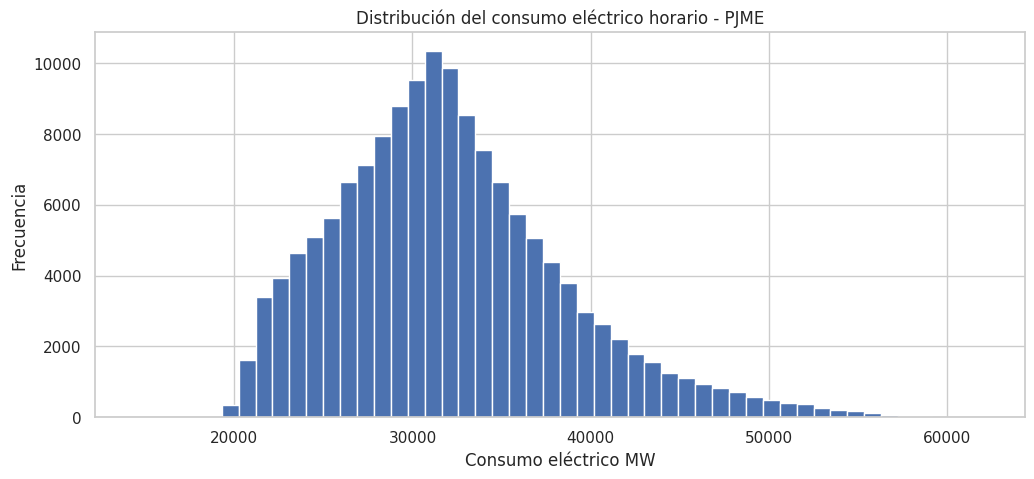

In [17]:
# ============================================================
# 16. HISTOGRAMA DEL CONSUMO ELÉCTRICO
# ============================================================

plt.figure(figsize=(12, 5))
plt.hist(df['PJME_MW'], bins=50)
plt.title('Distribución del consumo eléctrico horario - PJME')
plt.xlabel('Consumo eléctrico MW')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

El histograma permite observar la frecuencia con la que aparecen distintos niveles de consumo eléctrico.

En este tipo de series es habitual encontrar una distribución amplia, ya que la demanda varía según la hora del día, el día de la semana y la estación del año.

## 13. Patrón horario de consumo

Uno de los patrones más importantes en la demanda eléctrica es el comportamiento por hora del día.

El consumo eléctrico suele variar significativamente entre la madrugada, la jornada laboral, la tarde y la noche. Analizar este patrón permite identificar las horas de mayor y menor demanda promedio.

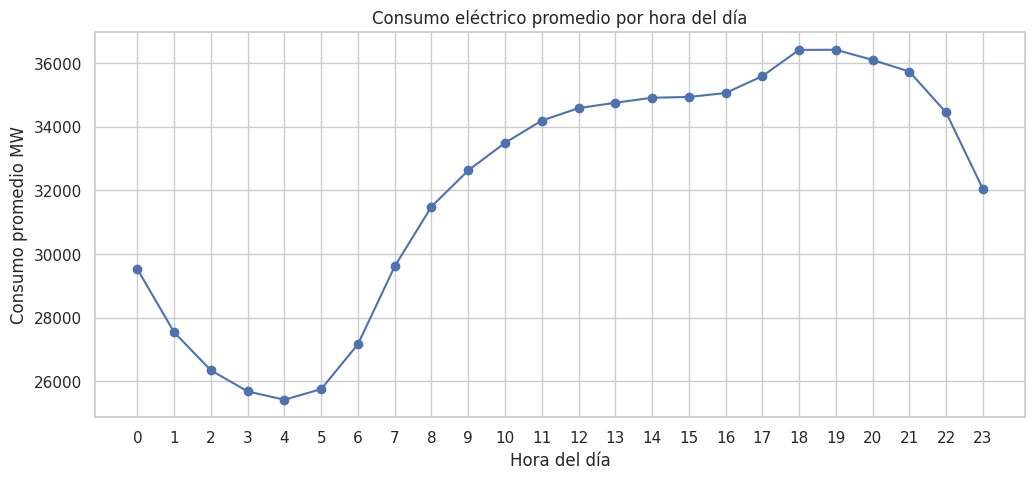

In [18]:
# ============================================================
# 17. PATRÓN PROMEDIO POR HORA DEL DÍA
# ============================================================

hourly_pattern = df.groupby('hour')['PJME_MW'].mean()

plt.figure(figsize=(12, 5))
plt.plot(hourly_pattern.index, hourly_pattern.values, marker='o')
plt.title('Consumo eléctrico promedio por hora del día')
plt.xlabel('Hora del día')
plt.ylabel('Consumo promedio MW')
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

In [19]:
# ============================================================
# 18. TABLA DE CONSUMO PROMEDIO POR HORA
# ============================================================

hourly_pattern_df = hourly_pattern.reset_index()
hourly_pattern_df.columns = ['hour', 'avg_demand_MW']

hourly_pattern_df.sort_values('avg_demand_MW', ascending=False).head(10)

,hour,avg_demand_MW
19,19,"36,426.63"
18,18,"36,421.93"
20,20,"36,106.84"
21,21,"35,741.06"
17,17,"35,596.05"
16,16,"35,065.39"
15,15,"34,940.67"
14,14,"34,916.60"
13,13,"34,759.57"
12,12,"34,588.62"


El análisis horario permite identificar las horas del día en que la demanda eléctrica promedio tiende a ser más alta.

Este patrón es fundamental para el modelamiento predictivo, ya que la hora del día suele ser una de las variables más relevantes en modelos de forecasting de consumo eléctrico.

## 14. Patrón semanal de consumo

Además del patrón horario, la demanda eléctrica puede presentar diferencias importantes según el día de la semana.

En muchos sistemas eléctricos, los días laborales presentan dinámicas distintas a los fines de semana debido a cambios en la actividad industrial, comercial y residencial.

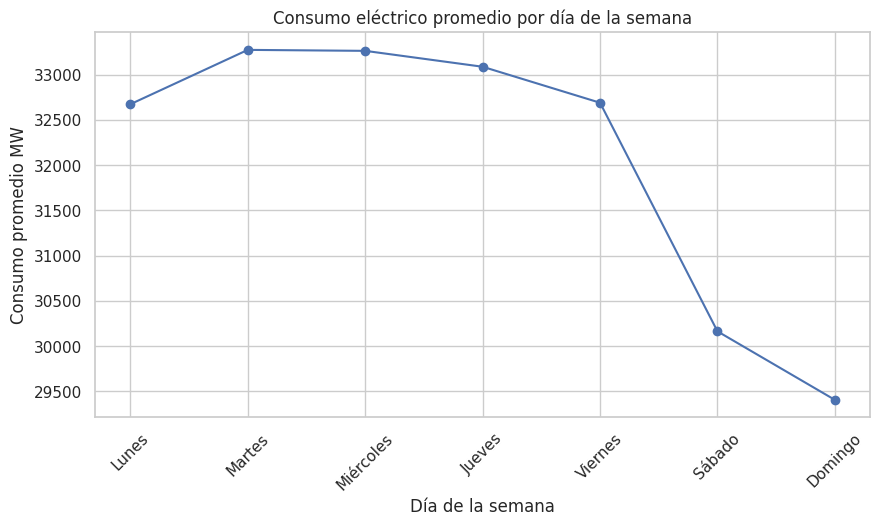

In [20]:
# ============================================================
# 19. PATRÓN PROMEDIO POR DÍA DE LA SEMANA
# ============================================================

weekly_pattern = df.groupby('dayofweek')['PJME_MW'].mean()

plt.figure(figsize=(10, 5))
plt.plot(weekly_pattern.index, weekly_pattern.values, marker='o')
plt.title('Consumo eléctrico promedio por día de la semana')
plt.xlabel('Día de la semana')
plt.ylabel('Consumo promedio MW')
plt.xticks(
    ticks=range(0, 7),
    labels=['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo'],
    rotation=45
)
plt.grid(True)
plt.show()

In [21]:
# ============================================================
# 21. TABLA DE CONSUMO PROMEDIO POR DÍA DE LA SEMANA
# ============================================================

weekly_pattern_df = weekly_pattern.reset_index()
weekly_pattern_df.columns = ['dayofweek', 'avg_demand_MW']

day_names = {
    0: 'Lunes',
    1: 'Martes',
    2: 'Miércoles',
    3: 'Jueves',
    4: 'Viernes',
    5: 'Sábado',
    6: 'Domingo'
}

weekly_pattern_df['day_name'] = weekly_pattern_df['dayofweek'].map(day_names)

weekly_pattern_df.sort_values('avg_demand_MW', ascending=False)

,dayofweek,avg_demand_MW,day_name
1,1,"33,272.27",Martes
2,2,"33,261.50",Miércoles
3,3,"33,085.86",Jueves
4,4,"32,688.23",Viernes
0,0,"32,672.03",Lunes
5,5,"30,162.88",Sábado
6,6,"29,405.85",Domingo


El patrón semanal permite comparar la demanda promedio entre días laborales y fines de semana.

Esta información es relevante porque ayuda a identificar si la serie presenta ciclos asociados a la actividad económica y social durante la semana.

## 15. Patrón mensual y estacionalidad anual

La demanda eléctrica también puede presentar patrones estacionales a lo largo del año.

Estos patrones suelen estar asociados a cambios climáticos, temperatura, uso de calefacción, aire acondicionado, actividad económica y comportamiento residencial.

En esta sección se analiza el consumo promedio por mes para identificar posibles ciclos estacionales.

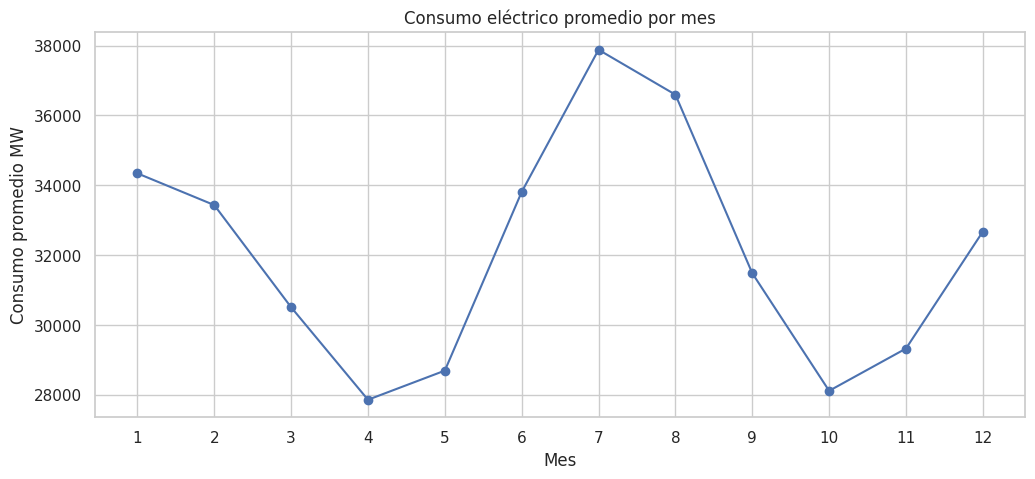

In [22]:
# ============================================================
# 22. PATRÓN PROMEDIO POR MES
# ============================================================

monthly_pattern = df.groupby('month')['PJME_MW'].mean()

plt.figure(figsize=(12, 5))
plt.plot(monthly_pattern.index, monthly_pattern.values, marker='o')
plt.title('Consumo eléctrico promedio por mes')
plt.xlabel('Mes')
plt.ylabel('Consumo promedio MW')
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

In [23]:
# ============================================================
# 23. TABLA DE CONSUMO PROMEDIO POR MES
# ============================================================

monthly_pattern_df = monthly_pattern.reset_index()
monthly_pattern_df.columns = ['month', 'avg_demand_MW']

month_names = {
    1: 'Enero',
    2: 'Febrero',
    3: 'Marzo',
    4: 'Abril',
    5: 'Mayo',
    6: 'Junio',
    7: 'Julio',
    8: 'Agosto',
    9: 'Septiembre',
    10: 'Octubre',
    11: 'Noviembre',
    12: 'Diciembre'
}

monthly_pattern_df['month_name'] = monthly_pattern_df['month'].map(month_names)

monthly_pattern_df.sort_values('avg_demand_MW', ascending=False)

,month,avg_demand_MW,month_name
6,7,"37,881.97",Julio
7,8,"36,595.96",Agosto
0,1,"34,343.25",Enero
5,6,"33,811.80",Junio
1,2,"33,434.97",Febrero
11,12,"32,676.48",Diciembre
8,9,"31,484.05",Septiembre
2,3,"30,510.02",Marzo
10,11,"29,327.69",Noviembre
4,5,"28,695.36",Mayo


El análisis mensual permite observar si existen meses con mayor demanda promedio.

En sistemas eléctricos, estos patrones suelen estar fuertemente relacionados con condiciones estacionales. Por ejemplo, los meses de verano o invierno pueden presentar mayor consumo debido al uso intensivo de sistemas de climatización.

## 16. Evolución anual de la demanda eléctrica

Además de los patrones intra-anuales, es importante analizar la evolución de la demanda a nivel anual.

Este análisis permite observar si el consumo promedio ha aumentado, disminuido o se ha mantenido relativamente estable durante el período histórico disponible.

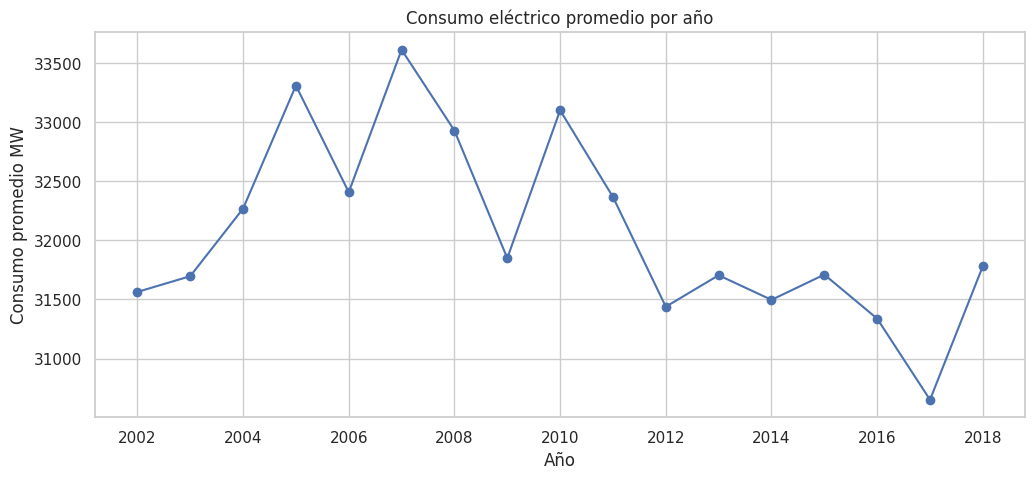

In [24]:
# ============================================================
# 24. CONSUMO PROMEDIO POR AÑO
# ============================================================

yearly_pattern = df.groupby('year')['PJME_MW'].mean()

plt.figure(figsize=(12, 5))
plt.plot(yearly_pattern.index, yearly_pattern.values, marker='o')
plt.title('Consumo eléctrico promedio por año')
plt.xlabel('Año')
plt.ylabel('Consumo promedio MW')
plt.grid(True)
plt.show()

In [25]:
# ============================================================
# 25. TABLA DE CONSUMO PROMEDIO POR AÑO
# ============================================================

yearly_pattern_df = yearly_pattern.reset_index()
yearly_pattern_df.columns = ['year', 'avg_demand_MW']

yearly_pattern_df

,year,avg_demand_MW
0,2002,"31,563.70"
1,2003,"31,696.65"
2,2004,"32,268.23"
3,2005,"33,308.36"
4,2006,"32,407.06"
5,2007,"33,611.36"
6,2008,"32,927.88"
7,2009,"31,849.28"
8,2010,"33,099.39"
9,2011,"32,366.50"


La evolución anual permite evaluar tendencias generales de largo plazo en la demanda eléctrica.

Este análisis es útil para identificar posibles cambios estructurales en el consumo, aunque para confirmar una tendencia sería necesario complementar la visualización con técnicas estadísticas o modelos específicos de series de tiempo.

## 17. Mapa de calor: hora del día vs día de la semana

Para visualizar simultáneamente el patrón horario y semanal, se construye una matriz de consumo promedio según hora del día y día de la semana.

Este tipo de visualización permite identificar franjas horarias de alta demanda y comparar si el comportamiento cambia entre días laborales y fines de semana.

In [26]:
# ============================================================
# 26. MATRIZ HORA VS DÍA DE LA SEMANA
# ============================================================

heatmap_data = df.pivot_table(
    values='PJME_MW',
    index='hour',
    columns='dayofweek',
    aggfunc='mean'
)

heatmap_data.columns = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

heatmap_data

,Lunes,Martes,Miércoles,Jueves,Viernes,Sábado,Domingo
hour,,,,,,,
0,"28,529.78","29,831.18","30,043.36","30,020.83","29,985.96","29,642.72","28,616.58"
1,"26,734.91","27,788.00","27,954.89","27,937.34","27,915.33","27,627.63","26,789.79"
2,"25,692.81","26,609.14","26,757.68","26,731.43","26,704.65","26,333.37","25,554.23"
3,"25,174.36","25,979.33","26,106.43","26,071.67","26,046.41","25,557.09","24,798.20"
4,"25,071.05","25,774.56","25,878.04","25,843.71","25,810.89","25,143.01","24,381.76"
5,"25,634.90","26,279.50","26,350.68","26,306.41","26,245.01","25,127.18","24,300.38"
6,"27,457.40","28,132.18","28,195.19","28,116.67","27,967.60","25,653.54","24,613.97"
7,"30,494.81","31,339.48","31,390.85","31,254.29","30,962.82","26,611.24","25,217.87"
8,"32,650.76","33,494.89","33,527.85","33,376.99","33,086.30","28,011.02","26,281.13"


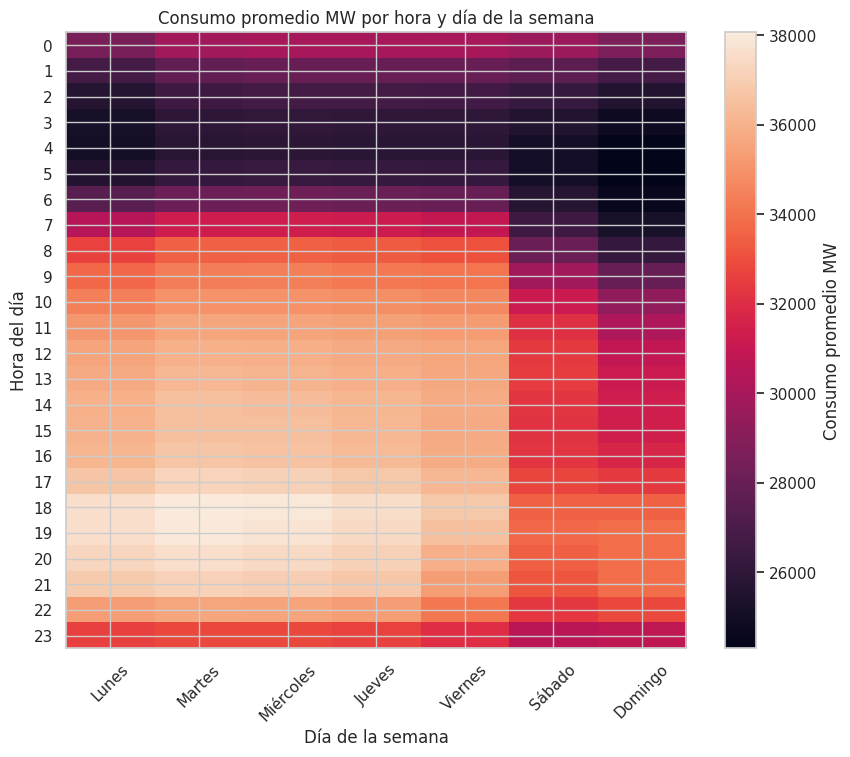

In [27]:
# ============================================================
# 27. HEATMAP HORA VS DÍA DE LA SEMANA
# ============================================================

plt.figure(figsize=(10, 8))
plt.imshow(heatmap_data, aspect='auto')
plt.title('Consumo promedio MW por hora y día de la semana')
plt.xlabel('Día de la semana')
plt.ylabel('Hora del día')
plt.xticks(ticks=range(7), labels=heatmap_data.columns, rotation=45)
plt.yticks(ticks=range(24), labels=range(24))
plt.colorbar(label='Consumo promedio MW')
plt.show()

El mapa de calor permite observar de manera integrada cómo cambia la demanda eléctrica según la hora del día y el día de la semana.

Las zonas de mayor intensidad representan períodos de mayor consumo promedio, mientras que las zonas de menor intensidad reflejan períodos de menor demanda relativa.

## 18. Detección inicial de peak demand

Uno de los aspectos más relevantes en la gestión eléctrica es la identificación de períodos de alta demanda o `peak demand`.

Estos eventos son importantes porque pueden tensionar la operación del sistema eléctrico, requerir mayor capacidad de generación y afectar decisiones de planificación energética.

En esta primera aproximación se identificarán los registros que se encuentran sobre el percentil 95 de consumo.

In [28]:
# ============================================================
# 28. DEFINICIÓN DE UMBRAL DE PEAK DEMAND
# ============================================================

peak_threshold = df['PJME_MW'].quantile(0.95)

print(f"Umbral de peak demand percentil 95: {peak_threshold:,.2f} MW")

Umbral de peak demand percentil 95: 44,187.00 MW


In [29]:
# ============================================================
# 29. IDENTIFICACIÓN DE REGISTROS DE PEAK DEMAND
# ============================================================

df['is_peak_demand'] = np.where(df['PJME_MW'] >= peak_threshold, 1, 0)

peak_events = df[df['is_peak_demand'] == 1]

print("Cantidad de registros peak demand:", len(peak_events))
print("Porcentaje del total:", round(len(peak_events) / len(df) * 100, 2), "%")

peak_events.head()

Cantidad de registros peak demand: 7272
Porcentaje del total: 5.0 %


,PJME_MW,hour,dayofweek,dayofmonth,dayofyear,weekofyear,month,quarter,year,is_peak_demand
Datetime,,,,,,,,,,
2002-04-17 17:00:00,"44,537.00",17,2,17,107,16,4,2,2002,1
2002-04-17 18:00:00,"44,332.00",18,2,17,107,16,4,2,2002,1
2002-06-05 15:00:00,"44,615.00",15,2,5,156,23,6,2,2002,1
2002-06-05 16:00:00,"45,533.00",16,2,5,156,23,6,2,2002,1
2002-06-05 17:00:00,"46,006.00",17,2,5,156,23,6,2,2002,1


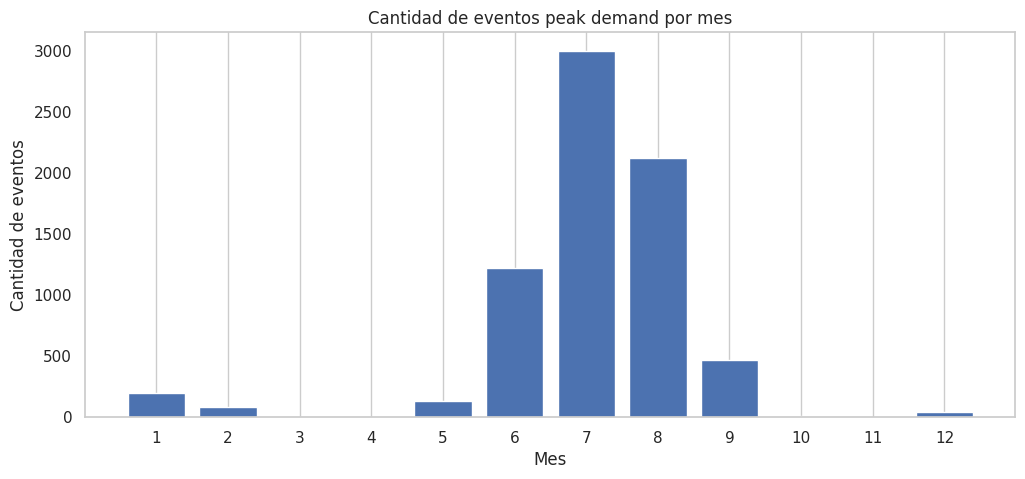

In [30]:
# ============================================================
# 30. DISTRIBUCIÓN DE PEAK DEMAND POR MES
# ============================================================

peak_by_month = peak_events.groupby('month').size()

plt.figure(figsize=(12, 5))
plt.bar(peak_by_month.index, peak_by_month.values)
plt.title('Cantidad de eventos peak demand por mes')
plt.xlabel('Mes')
plt.ylabel('Cantidad de eventos')
plt.xticks(range(1, 13))
plt.grid(axis='y')
plt.show()

La detección de peak demand permite identificar los períodos donde la demanda eléctrica se ubica dentro del 5% más alto de toda la serie histórica.

Este análisis entrega una primera visión sobre la concentración temporal de los eventos de alta demanda y puede ser utilizado posteriormente para análisis de riesgo operacional, planificación de capacidad o diseño de estrategias de respuesta ante demanda.

## 19. Conclusiones preliminares del análisis exploratorio

En esta primera etapa del proyecto se realizó una exploración inicial del consumo eléctrico horario de la zona PJME.

A partir del análisis se observaron elementos clave para el desarrollo posterior del modelo predictivo:

1. La serie cuenta con una estructura temporal horaria adecuada para forecasting.
2. La demanda eléctrica presenta variabilidad relevante a lo largo del tiempo.
3. Existen patrones diferenciados según la hora del día.
4. El consumo varía según el día de la semana, lo que sugiere comportamiento asociado a ciclos laborales y residenciales.
5. La demanda promedio cambia entre meses, evidenciando posible estacionalidad anual.
6. Los eventos de peak demand pueden identificarse mediante umbrales estadísticos como el percentil 95.

Estos hallazgos justifican avanzar hacia una etapa de preparación de datos para modelamiento, incorporando variables temporales, rezagos de demanda y validación temporal.

## Segunda fase del proyecto: modelamiento predictivo y valor de negocio

Luego de realizar la exploración inicial de la demanda eléctrica horaria, el proyecto avanza hacia una etapa de modelamiento predictivo.

El objetivo de esta fase es construir modelos capaces de estimar la demanda eléctrica futura utilizando patrones históricos, variables temporales, rezagos y promedios móviles.

Además del desempeño técnico, esta etapa busca conectar los resultados del modelo con posibles aplicaciones reales para empresas eléctricas, operadores del sistema, grandes consumidores, gestores energéticos y usuarios finales.

## 20. Preparación del dataset para forecasting

Para construir modelos predictivos, se requiere transformar la serie temporal en una estructura supervisada.

Esto significa que la variable objetivo será la demanda eléctrica futura, mientras que las variables explicativas incluirán información temporal, rezagos de consumo y promedios móviles.

Este enfoque permite que modelos de machine learning aprendan patrones históricos asociados al comportamiento horario, semanal y estacional de la demanda eléctrica.

In [31]:
# ============================================================
# 31. CREACIÓN DE VARIABLES PARA FORECASTING
# ============================================================

# Copia del dataframe tratado para modelamiento
model_df = df.copy()

# Rezagos horarios
model_df['lag_1'] = model_df['PJME_MW'].shift(1)       # hora anterior
model_df['lag_24'] = model_df['PJME_MW'].shift(24)     # mismo horario del día anterior
model_df['lag_168'] = model_df['PJME_MW'].shift(168)   # mismo horario de la semana anterior

# Promedios móviles históricos
model_df['rolling_24'] = model_df['PJME_MW'].shift(1).rolling(window=24).mean()
model_df['rolling_168'] = model_df['PJME_MW'].shift(1).rolling(window=168).mean()

# Variables cíclicas para capturar periodicidad
model_df['hour_sin'] = np.sin(2 * np.pi * model_df['hour'] / 24)
model_df['hour_cos'] = np.cos(2 * np.pi * model_df['hour'] / 24)
model_df['month_sin'] = np.sin(2 * np.pi * model_df['month'] / 12)
model_df['month_cos'] = np.cos(2 * np.pi * model_df['month'] / 12)
model_df['dayofweek_sin'] = np.sin(2 * np.pi * model_df['dayofweek'] / 7)
model_df['dayofweek_cos'] = np.cos(2 * np.pi * model_df['dayofweek'] / 7)

# Eliminación de registros con nulos generados por rezagos y ventanas móviles
model_df = model_df.dropna()

print("Dimensiones del dataset original:", df.shape)
print("Dimensiones del dataset para modelamiento:", model_df.shape)

model_df.head()

Dimensiones del dataset original: (145392, 10)
Dimensiones del dataset para modelamiento: (145224, 21)


,PJME_MW,hour,dayofweek,dayofmonth,dayofyear,weekofyear,month,quarter,year,is_peak_demand,lag_1,lag_24,lag_168,rolling_24,rolling_168,hour_sin,hour_cos,month_sin,month_cos,dayofweek_sin,dayofweek_cos
Datetime,,,,,,,,,,,,,,,,,,,,,
2002-01-08 01:00:00,"29,445.00",1,1,8,8,2,1,1,2002,0,"31,187.00","26,862.00","30,393.00","33,452.58","32,519.51",0.26,0.97,0.50,0.87,0.78,0.62
2002-01-08 02:00:00,"28,670.00",2,1,8,8,2,1,1,2002,0,"29,445.00","25,976.00","29,265.00","33,560.21","32,513.87",0.50,0.87,0.50,0.87,0.78,0.62
2002-01-08 03:00:00,"28,375.00",3,1,8,8,2,1,1,2002,0,"28,670.00","25,641.00","28,357.00","33,672.46","32,510.33",0.71,0.71,0.50,0.87,0.78,0.62
2002-01-08 04:00:00,"28,542.00",4,1,8,8,2,1,1,2002,0,"28,375.00","25,666.00","27,899.00","33,786.38","32,510.43",0.87,0.50,0.50,0.87,0.78,0.62
2002-01-08 05:00:00,"29,261.00",5,1,8,8,2,1,1,2002,0,"28,542.00","26,328.00","28,057.00","33,906.21","32,514.26",0.97,0.26,0.50,0.87,0.78,0.62


Se incorporan rezagos de demanda para entregar memoria temporal al modelo:

- `lag_1`: consumo de la hora anterior.
- `lag_24`: consumo del mismo horario del día anterior.
- `lag_168`: consumo del mismo horario de la semana anterior.

También se agregan promedios móviles de 24 y 168 horas para capturar tendencia reciente diaria y semanal.

Las variables cíclicas permiten representar correctamente patrones horarios, semanales y mensuales, evitando que el modelo interprete variables como la hora 23 y la hora 0 como valores lejanos cuando en realidad son temporalmente consecutivos.

## 21. Separación temporal entre entrenamiento y prueba

En problemas de series de tiempo no se debe dividir el dataset de forma aleatoria, ya que eso provocaría fuga de información desde el futuro hacia el pasado.

Por esta razón, se utilizará una separación temporal: los datos más antiguos serán usados para entrenamiento y el último período histórico será reservado para prueba.

En esta primera versión, se utilizará el último año de datos como conjunto de prueba.

In [32]:
# ============================================================
# 32. DEFINICIÓN DE VARIABLES PREDICTORAS Y OBJETIVO
# ============================================================

target = 'PJME_MW'

features = [
    'hour', 'dayofweek', 'dayofmonth', 'dayofyear', 'weekofyear',
    'month', 'quarter', 'year',
    'hour_sin', 'hour_cos',
    'month_sin', 'month_cos',
    'dayofweek_sin', 'dayofweek_cos',
    'lag_1', 'lag_24', 'lag_168',
    'rolling_24', 'rolling_168'
]

X = model_df[features]
y = model_df[target]

print("Cantidad de variables predictoras:", len(features))
print("Variable objetivo:", target)

Cantidad de variables predictoras: 19
Variable objetivo: PJME_MW


In [33]:
# ============================================================
# 33. SPLIT TEMPORAL TRAIN / TEST
# ============================================================

# Se reserva el último año como período de prueba.
test_start_date = model_df.index.max() - pd.DateOffset(years=1)

train = model_df[model_df.index < test_start_date]
test = model_df[model_df.index >= test_start_date]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print("Fecha de inicio train:", train.index.min())
print("Fecha de término train:", train.index.max())
print("Fecha de inicio test:", test.index.min())
print("Fecha de término test:", test.index.max())
print("Registros train:", len(train))
print("Registros test:", len(test))

Fecha de inicio train: 2002-01-08 01:00:00
Fecha de término train: 2017-08-02 23:00:00
Fecha de inicio test: 2017-08-03 00:00:00
Fecha de término test: 2018-08-03 00:00:00
Registros train: 136463
Registros test: 8761


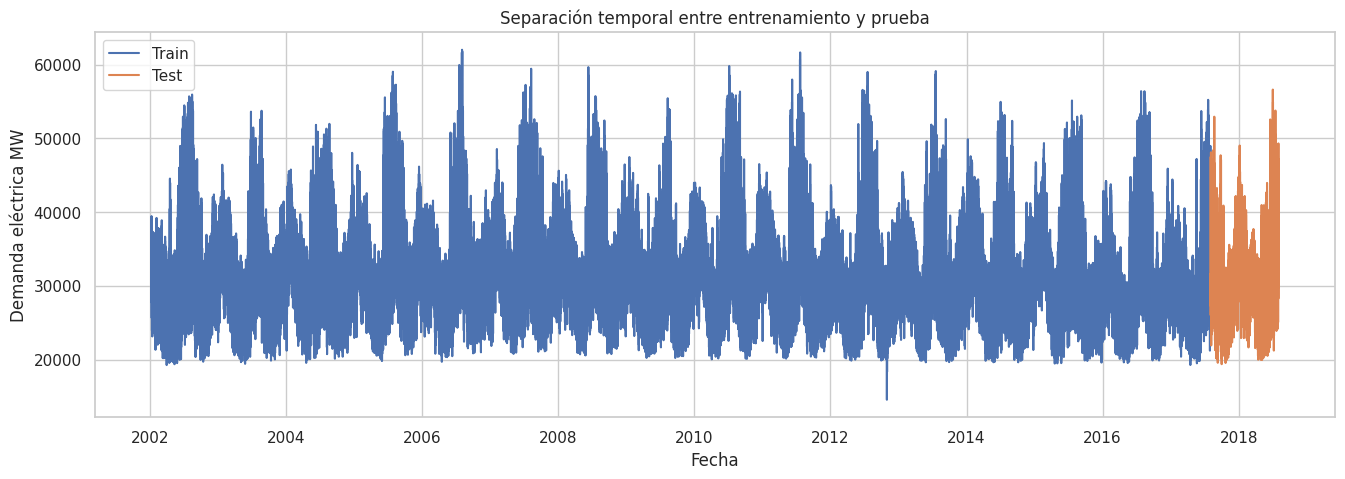

In [34]:
# ============================================================
# 34. VISUALIZACIÓN DEL SPLIT TEMPORAL
# ============================================================

plt.figure(figsize=(16, 5))
plt.plot(train.index, train[target], label='Train')
plt.plot(test.index, test[target], label='Test')
plt.title('Separación temporal entre entrenamiento y prueba')
plt.xlabel('Fecha')
plt.ylabel('Demanda eléctrica MW')
plt.legend()
plt.grid(True)
plt.show()

La separación temporal permite evaluar el desempeño del modelo en un período futuro no utilizado durante el entrenamiento.

Esta estrategia es más realista para un problema de forecasting, ya que simula el escenario en que el modelo debe predecir datos que todavía no conoce.

## 22. Métricas de evaluación

Para comparar modelos se utilizarán métricas comunes en problemas de regresión y forecasting:

- **MAE**: error absoluto medio. Mide el error promedio en las mismas unidades de la variable objetivo.
- **RMSE**: penaliza con mayor fuerza errores grandes.
- **MAPE**: expresa el error como porcentaje respecto del valor real.

Estas métricas permiten comparar modelos desde distintas perspectivas: error medio, sensibilidad a errores grandes y error relativo porcentual.

In [35]:
# ============================================================
# 35. FUNCIÓN DE EVALUACIÓN DE MODELOS
# ============================================================

def evaluate_forecast(y_true, y_pred, model_name):
    """
    Calcula métricas principales para evaluar modelos de forecasting.
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    
    results = {
        'model': model_name,
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'MAPE_%': round(mape, 2)
    }
    
    return results

Para mantener claridad y consistencia en la comparación de modelos, las métricas se reportarán con dos decimales.

- `MAE`: 2 decimales, expresado en MW.
- `RMSE`: 2 decimales, expresado en MW.
- `MAPE`: 2 decimales, expresado como porcentaje.

Además, para la presentación en español se utilizará el formato numérico habitual:

- Separador de miles: punto.
- Separador decimal: coma.

Ejemplo:

- `2.306,94 MW`
- `4.146,19 MW`
- `7,32%`

Para los cálculos internos se mantendrá el formato numérico estándar de Python, donde el punto se usa como separador decimal. Esto evita errores en operaciones matemáticas, modelos y métricas.

La conversión a formato español se aplicará solo al momento de presentar resultados en tablas, textos Markdown o reportes ejecutivos.

In [36]:
# ============================================================
# 35.1 FUNCIÓN AUXILIAR DE FORMATO NUMÉRICO EN ESPAÑOL
# ============================================================

def format_spanish_number(value, decimals=2):
    """
    Convierte un número al formato usado en español:
    - punto como separador de miles
    - coma como separador decimal
    
    Ejemplo:
    2306.94 -> '2.306,94'
    """
    formatted = f"{value:,.{decimals}f}"
    formatted = formatted.replace(",", "X").replace(".", ",").replace("X", ".")
    return formatted

In [37]:
# ============================================================
# 35.2 FUNCIÓN PARA MOSTRAR RESULTADOS EN FORMATO ESPAÑOL
# ============================================================

def display_forecast_results(results_dict):
    """
    Recibe un diccionario de métricas y devuelve una versión formateada
    para presentación en español.
    """
    return {
        'Modelo': results_dict['model'],
        'MAE': f"{format_spanish_number(results_dict['MAE'])} MW",
        'RMSE': f"{format_spanish_number(results_dict['RMSE'])} MW",
        'MAPE': f"{format_spanish_number(results_dict['MAPE_%'])}%"
    }

## 22. Modelo baseline naive

Antes de entrenar modelos avanzados, se construye un modelo base o `baseline`.

El baseline permite establecer un punto mínimo de comparación. Si un modelo avanzado no supera al baseline, entonces no justifica su complejidad adicional.

En este caso se usará como predicción el valor de demanda observado 24 horas antes, asumiendo que el consumo horario de hoy se parece al del mismo horario del día anterior.

In [38]:
# ============================================================
# 36. MODELO BASELINE NAIVE 24 HORAS
# ============================================================

y_pred_naive = test['lag_24']

baseline_results = evaluate_forecast(y_test, y_pred_naive, 'Baseline Naive lag_24')
baseline_results

{'model': 'Baseline Naive lag_24',
 'MAE': 2306.93,
 'RMSE': np.float64(3146.19),
 'MAPE_%': 7.32}

<function matplotlib.pyplot.show(close=None, block=None)>

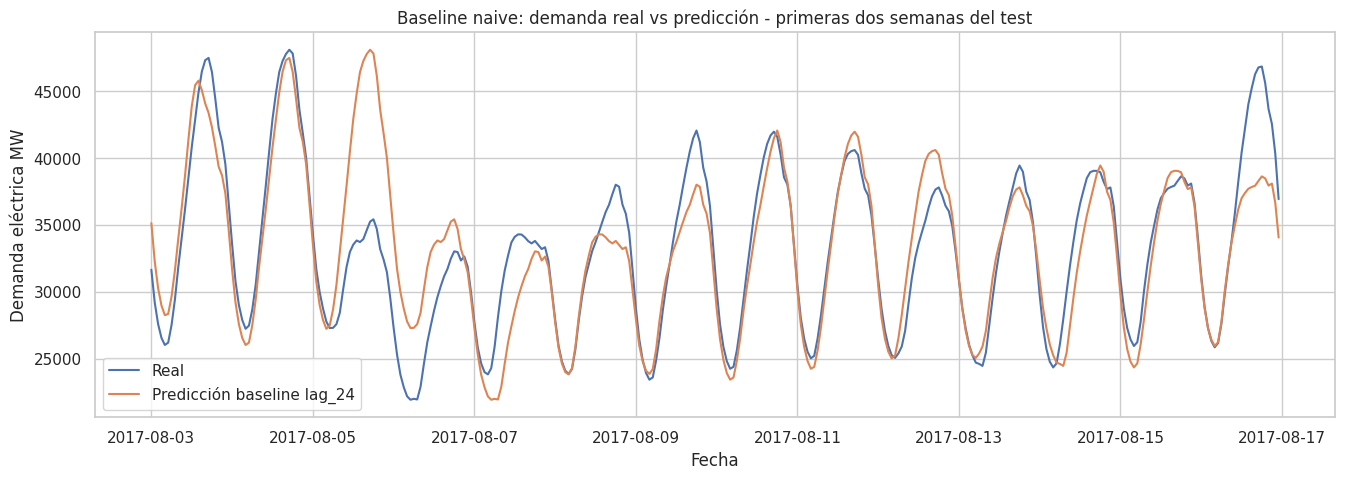

In [39]:
# ============================================================
# 37. VISUALIZACIÓN DEL BASELINE EN UNA VENTANA DE PRUEBA
# ============================================================

sample_days = 14
sample_test = test.iloc[:24 * sample_days].copy()
sample_pred = y_pred_naive.iloc[:24 * sample_days]

plt.figure(figsize=(16, 5))
plt.plot(sample_test.index, sample_test[target], label='Real')
plt.plot(sample_test.index, sample_pred, label='Predicción baseline lag_24')
plt.title('Baseline naive: demanda real vs predicción - primeras dos semanas del test')
plt.xlabel('Fecha')
plt.ylabel('Demanda eléctrica MW')
plt.legend()
plt.grid(True)
plt.show

El modelo baseline entrega una primera referencia de desempeño.

Este modelo no aprende parámetros ni relaciones complejas, pero suele ser competitivo en series con patrones diarios marcados. Por eso es una comparación importante antes de avanzar hacia modelos de machine learning.

En esta primera evaluación, el modelo `Baseline Naive lag_24` obtuvo aproximadamente:

- MAE: 2306.93 MW.
- RMSE: 3146.19 MW.
- MAPE: 7.32%.

Estos resultados indican que, usando únicamente el consumo observado 24 horas antes, el modelo logra capturar una parte relevante del patrón diario de la demanda eléctrica. El MAPE cercano al 7% sugiere que el baseline es razonablemente competitivo para una primera aproximación. Además, la diferencia entre MAE y RMSE muestra que existen errores más altos en ciertos momentos puntuales, pero no tan extremos como para desestabilizar completamente el desempeño general del modelo.

Sin embargo, el gráfico de las primeras dos semanas del período de prueba muestra que el modelo tiende a replicar bien la forma general del ciclo diario, pero presenta dificultades cuando existen cambios bruscos de nivel o peaks de demanda. En esos períodos, la predicción puede quedar desplazada respecto de la demanda real, especialmente cuando el comportamiento de un día no se parece al del día anterior.

Este resultado confirma que el patrón diario es una señal fuerte dentro de la serie, pero también evidencia la necesidad de incorporar modelos más flexibles y variables adicionales que capturen efectos semanales, estacionales, climáticos o eventos atípicos.

Desde una perspectiva de negocio energético, este baseline ya entrega una señal útil: la demanda de una hora determinada suele parecerse bastante al consumo registrado en la misma hora del día anterior.

Esto podría servir como una regla operacional simple para construir alertas tempranas básicas. Sin embargo, para aplicaciones de mayor valor, como gestión de peak demand, planificación de capacidad o recomendaciones de ahorro energético, se requiere mejorar la precisión en momentos críticos.

El principal riesgo del baseline es que puede fallar justo cuando más importa: cambios bruscos, peaks de demanda o días con patrones distintos al día anterior. Por eso, los siguientes modelos deberán buscar reducir el error en esos puntos, no solo mejorar el promedio general.

## 23. Modelo de Regresión Lineal

Como primer modelo supervisado se utiliza una regresión lineal.

Este modelo permite evaluar si una combinación lineal de variables temporales, rezagos y promedios móviles es suficiente para aproximar la demanda eléctrica horaria.

Aunque puede ser limitado para capturar relaciones no lineales complejas, entrega una referencia interpretable y sencilla.

In [40]:
# ============================================================
# 38. ENTRENAMIENTO DE REGRESIÓN LINEAL
# ============================================================

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

lr_results = evaluate_forecast(y_test, y_pred_lr, 'Linear Regression')
lr_results

{'model': 'Linear Regression',
 'MAE': 785.51,
 'RMSE': np.float64(1004.98),
 'MAPE_%': 2.48}

In [41]:
# ============================================================
# 39. COEFICIENTES DE LA REGRESIÓN LINEAL
# ============================================================

coef_df = pd.DataFrame({
    'feature': features,
    'coefficient': lr_model.coef_
}).sort_values('coefficient', ascending=False)

coef_df

,feature,coefficient
8,hour_sin,745.55
13,dayofweek_cos,167.26
0,hour,53.15
6,quarter,26.16
3,dayofyear,6.79
10,month_sin,5.39
4,weekofyear,2.44
14,lag_1,0.83
15,lag_24,0.10
17,rolling_24,0.08


La regresión lineal permite tener una primera aproximación interpretable del problema.

En esta evaluación, el modelo de `Linear Regression` obtuvo los siguientes resultados:

- MAE: 785.51 MW.
- RMSE: 1004.98 MW.
- MAPE: 2.48%.

Estos resultados muestran una mejora significativa respecto del modelo `Baseline Naive lag_24`, que había obtenido un MAE de 2306.93 MW, un RMSE de 3146.19 MW y un MAPE de 7.32%.

La reducción del MAPE desde 7.32% a 2.48% indica que la regresión lineal logra capturar de mejor manera la estructura temporal de la demanda eléctrica cuando combina variables de calendario, variables cíclicas, rezagos y promedios móviles.

Desde el punto de vista técnico, este resultado es relevante porque demuestra que un modelo simple e interpretable puede superar ampliamente a una regla naive basada solo en el consumo del día anterior.

La revisión de coeficientes muestra que las variables cíclicas asociadas a la hora del día tienen un peso relevante dentro del modelo. En particular, `hour_sin` presenta un coeficiente positivo importante, mientras que `hour_cos` presenta un coeficiente negativo alto. Esto sugiere que el modelo está capturando el ciclo diario de la demanda eléctrica mediante la representación trigonométrica de la hora.

También aparecen efectos asociados al día de la semana, especialmente a través de `dayofweek_cos` y `dayofweek_sin`, lo que confirma la existencia de un componente semanal en la demanda.

Los rezagos `lag_1`, `lag_24`, `lag_168` y los promedios móviles presentan coeficientes relativamente pequeños en comparación con las variables cíclicas. Esto no significa necesariamente que sean irrelevantes, sino que dentro de un modelo lineal su efecto marginal queda distribuido junto con otras variables temporales.

En términos prácticos, la regresión lineal se posiciona como un modelo base fuerte: mejora claramente el baseline, mantiene interpretabilidad y entrega una primera evidencia de que la demanda eléctrica puede modelarse de forma efectiva mediante variables temporales bien diseñadas.

coeficientes estimados por el modelo fueron:

| Variable | Coeficiente |
|---|---:|
| hour_sin | 745.55 |
| dayofweek_cos | 167.26 |
| hour | 53.15 |
| quarter | 26.16 |
| dayofyear | 6.79 |
| month_sin | 5.39 |
| weekofyear | 2.44 |
| lag_1 | 0.83 |
| lag_24 | 0.10 |
| rolling_24 | 0.08 |
| lag_168 | 0.07 |
| rolling_168 | -0.08 |
| year | -0.51 |
| dayofmonth | -7.66 |
| month_cos | -18.08 |
| dayofweek | -75.68 |
| dayofweek_sin | -119.57 |
| month | -225.20 |
| hour_cos | -982.16 |
|

La magnitud de `hour_sin` y `hour_cos` confirma que el ciclo horario es una de las señales más importantes para explicar la demanda eléctrica. El efecto de `dayofweek_sin` y `dayofweek_cos` sugiere que también existe una dinámica semanal relevante.

Los coeficientes de los rezagos son positivos, aunque de menor magnitud relativa. Esto indica que la memoria histórica reciente aporta información, pero en este modelo lineal la estructura cíclica del calendario parece dominar la explicación del comportamiento de la demanda.

Desde una perspectiva de negocio energético, la regresión lineal mejora de forma importante la regla operacional simple basada en el consumo del día anterior.

Esto es una conclusión relevante porque muestra que no siempre es necesario comenzar con modelos complejos para obtener mejoras predictivas significativas. Un modelo interpretable, bien alimentado con variables temporales y rezagos, puede entregar una primera solución robusta para anticipar demanda.

Con un MAPE de 2.48%, la regresión lineal podría ser considerada como una primera base para herramientas de planificación, monitoreo y alertas preliminares. Sin embargo, antes de utilizarla en decisiones críticas, todavía sería necesario analizar su comportamiento en períodos de peak demand, días atípicos y cambios bruscos de nivel.

El valor de este modelo no está solamente en su precisión, sino también en su interpretabilidad. Para una empresa, esto permite explicar por qué el modelo predice ciertos niveles de demanda y qué variables temporales influyen más en el resultado.

El siguiente paso natural es avanzar hacia modelos no lineales como Random Forest, XGBoost o LightGBM para evaluar si se puede mejorar aún más la precisión, especialmente en períodos críticos de alta demanda.

## 25. Modelo Random Forest

Random Forest es un modelo de ensamble basado en múltiples árboles de decisión.

Este tipo de modelo puede capturar relaciones no lineales entre variables y suele funcionar bien con variables de calendario, rezagos y promedios móviles.

En esta etapa se entrena un Random Forest base para comparar su desempeño contra el baseline naive y la regresión lineal.

In [42]:
# ============================================================
# 40. ENTRENAMIENTO DE RANDOM FOREST
# ============================================================

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_results = evaluate_forecast(y_test, y_pred_rf, 'Random Forest')
rf_results

{'model': 'Random Forest',
 'MAE': 316.64,
 'RMSE': np.float64(433.67),
 'MAPE_%': 0.99}

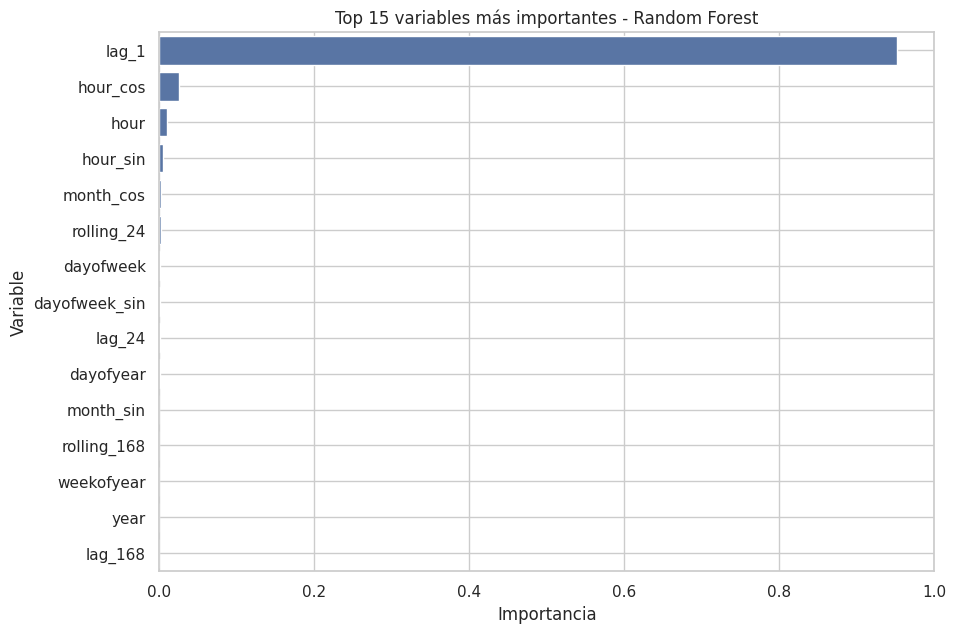

,feature,importance
14,lag_1,0.95
9,hour_cos,0.02
0,hour,0.01
8,hour_sin,0.01
11,month_cos,0.00
17,rolling_24,0.00
1,dayofweek,0.00
12,dayofweek_sin,0.00
15,lag_24,0.00
3,dayofyear,0.00


In [43]:
# ============================================================
# 41. IMPORTANCIA DE VARIABLES RANDOM FOREST
# ============================================================

importance_df = pd.DataFrame({
    'feature': features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(data=importance_df.head(15), x='importance', y='feature')
plt.title('Top 15 variables más importantes - Random Forest')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.grid(True)
plt.show()

importance_df.head(15)

El modelo `Random Forest` obtuvo los siguientes resultados:

- MAE: 316.64 MW.
- RMSE: 433.67 MW.
- MAPE: 0.99%.

Estos resultados representan una mejora significativa respecto de los modelos anteriores. En comparación con el `Baseline Naive lag_24`, el MAPE disminuye desde 7.32% a 0.99%. En comparación con la `Linear Regression`, el MAPE disminuye desde 2.48% a 0.99%.

Esto indica que Random Forest logra capturar relaciones no lineales y patrones temporales más complejos de la demanda eléctrica horaria. El modelo no solo utiliza variables de calendario, sino que también puede aprender interacciones entre rezagos, hora del día, ciclos diarios y otros componentes temporales.

La importancia de variables muestra que `lag_1` concentra la mayor parte del poder predictivo del modelo, con una importancia aproximada de 0.95. Esto significa que el consumo de la hora inmediatamente anterior es la señal más fuerte para estimar la demanda de la hora siguiente.

Después de `lag_1`, aparecen variables asociadas al ciclo horario, como `hour_cos`, `hour` y `hour_sin`, aunque con una importancia mucho menor. Esto confirma que el comportamiento reciente de la demanda domina la predicción, mientras que las variables de calendario aportan información complementaria.

El hecho de que `lag_24` y `lag_168` aparezcan con baja importancia relativa no significa que no sean útiles, sino que en este modelo el rezago inmediato contiene la señal más fuerte para el horizonte de predicción evaluado. Si el objetivo fuera predecir varios días hacia adelante, probablemente los rezagos diarios y semanales cobrarían mayor relevancia.

En términos técnicos, Random Forest se posiciona como el mejor modelo inicial dentro de esta comparación, superando tanto al baseline como a la regresión lineal en MAE, RMSE y MAPE.

Desde una perspectiva de negocio energético, el desempeño de Random Forest es especialmente relevante porque reduce el error promedio a un nivel cercano al 1% en términos de MAPE.

Esto sugiere que un modelo no lineal basado en datos históricos de consumo podría convertirse en una herramienta útil para monitoreo operativo, planificación de demanda y generación de alertas tempranas.

La alta importancia de `lag_1` indica que la demanda eléctrica tiene una fuerte dependencia de muy corto plazo. En aplicaciones reales, esto puede ser útil para sistemas de monitoreo casi en tiempo real, donde el consumo reciente permite anticipar el comportamiento inmediato del sistema.

Sin embargo, también aparece una advertencia importante: si el modelo depende demasiado del consumo de la hora anterior, podría tener menor capacidad para anticipar cambios abruptos causados por eventos externos, temperatura, feriados, fallas operacionales o cambios súbitos en la actividad económica.

Por esta razón, aunque Random Forest muestra un desempeño muy sólido, una aplicación empresarial debería complementarse con variables exógenas como clima, calendario laboral, tarifas eléctricas, eventos especiales y comportamiento sectorial.

Este resultado abre una línea clara de monetización: construir sistemas de alerta y dashboards predictivos que utilicen datos recientes de consumo para anticipar demanda de corto plazo y apoyar decisiones operacionales.

## 26. Comparación inicial de modelos

Una vez entrenados los primeros modelos, se comparan sus métricas de desempeño sobre el conjunto de prueba.

Esta comparación permite evaluar si los modelos supervisados logran mejorar el baseline naive y si la complejidad adicional se justifica en términos predictivos.

In [44]:
# ============================================================
# 42. COMPARACIÓN DE MODELOS
# ============================================================

results = pd.DataFrame([
    baseline_results,
    lr_results,
    rf_results
])

results = results.sort_values('MAE')
results

,model,MAE,RMSE,MAPE_%
2,Random Forest,316.64,433.67,0.99
1,Linear Regression,785.51,"1,004.98",2.48
0,Baseline Naive lag_24,"2,306.93","3,146.19",7.32


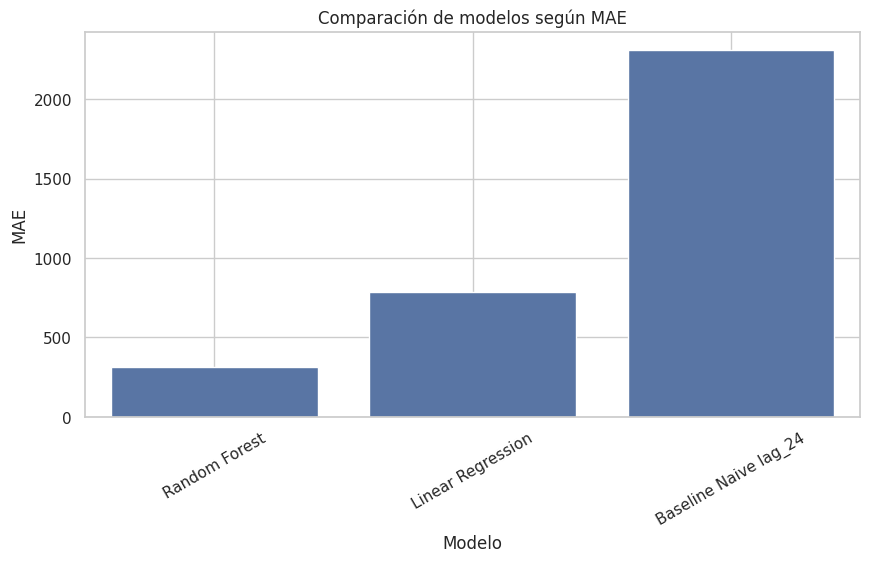

In [45]:
# ============================================================
# 43. VISUALIZACIÓN COMPARATIVA DE MÉTRICAS
# ============================================================

plt.figure(figsize=(10, 5))
sns.barplot(data=results, x='model', y='MAE')
plt.title('Comparación de modelos según MAE')
plt.xlabel('Modelo')
plt.ylabel('MAE')
plt.xticks(rotation=30)
plt.grid(True)
plt.show()

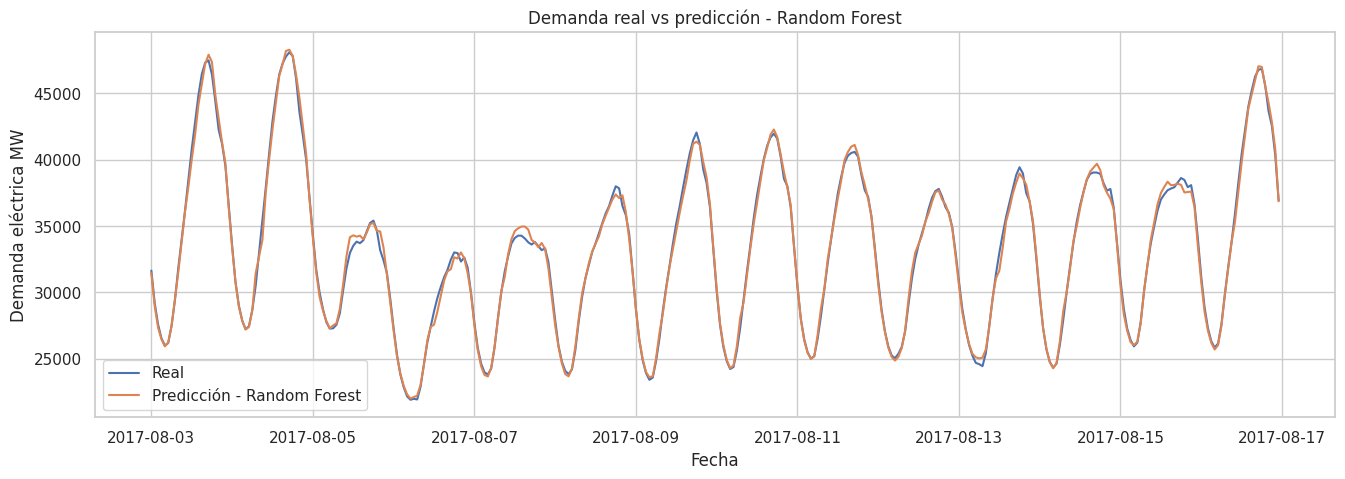

In [46]:
# ============================================================
# 44. VISUALIZACIÓN REAL VS PREDICCIÓN DEL MEJOR MODELO INICIAL
# ============================================================

best_model_name = results.iloc[0]['model']

if best_model_name == 'Baseline Naive lag_24':
    best_pred = y_pred_naive
elif best_model_name == 'Linear Regression':
    best_pred = pd.Series(y_pred_lr, index=y_test.index)
else:
    best_pred = pd.Series(y_pred_rf, index=y_test.index)

sample_days = 14

plt.figure(figsize=(16, 5))
plt.plot(y_test.iloc[:24 * sample_days].index, y_test.iloc[:24 * sample_days], label='Real')
plt.plot(best_pred.iloc[:24 * sample_days].index, best_pred.iloc[:24 * sample_days], label=f'Predicción - {best_model_name}')
plt.title(f'Demanda real vs predicción - {best_model_name}')
plt.xlabel('Fecha')
plt.ylabel('Demanda eléctrica MW')
plt.legend()
plt.grid(True)
plt.show()